# Exercises
1. Build a pipeline that handles a dataset with 3 numeric columns and 2 categorical columns. Use ColumnTransformer to apply median imputation + scaling to numerics and most-frequent imputation + one-hot encoding to categoricals. Train with 5-fold cross-validation.
2. Deliberately introduce data leakage: fit the scaler on the full dataset before splitting. Compare the cross-validation score (leaky) to the pipeline cross-validation score (clean). How large is the difference?
3. Serialize your pipeline with joblib.dump. Load it in a separate script and run predictions. Verify the predictions are identical.
4. Add a custom transformer to the pipeline that creates polynomial features (degree 2) for the two most important numeric columns. Where should it go in the pipeline?
5. Set up MLflow tracking for the pipeline. Run 5 experiments with different hyperparameters. Use the MLflow UI (mlflow ui) to compare runs and pick the best model.


### 1. Build a pipeline that handles a dataset with 3 numeric columns and 2 categorical columns. Use ColumnTransformer to apply median imputation + scaling to numerics and most-frequent imputation + one-hot encoding to categoricals. Train with 5-fold cross-validation.

In [42]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [43]:
# Example dataset
df = pd.DataFrame({
    "num1": [1.2, 2.3, None, 4.5, 5.1, 6.7, None, 8.9],
    "num2": [10, 20, 30, None, 50, 60, 70, 80],
    "num3": [100, None, 300, 400, 500, 600, 700, 800],
    "cat1": ["A", "B", "A", None, "C", "B", "A", "C"],
    "cat2": ["X", "Y", None, "X", "Z", "Y", "X", "Z"],
    "target": [0, 1, 0, 1, 0, 1, 0, 1]
})


In [44]:
df

,num1,num2,num3,cat1,cat2,target
0,1.2,10.0,100.0,A,X,0
1,2.3,20.0,NaN,B,Y,1
2,NaN,30.0,300.0,A,None,0
3,4.5,NaN,400.0,None,X,1
4,5.1,50.0,500.0,C,Z,0
5,6.7,60.0,600.0,B,Y,1
6,NaN,70.0,700.0,A,X,0
7,8.9,80.0,800.0,C,Z,1


In [45]:
X= df.drop("target",axis=1)
y= df["target"]

In [46]:
numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("standerd-scaler",StandardScaler()),
]
)

In [47]:
categorical_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore")),
]
)

In [48]:
preprocessor=ColumnTransformer([
    ("num",numeric_pipeline,["num1", "num2", "num3"]),
    ("cat",categorical_pipeline,["cat1", "cat2"]),
])

In [49]:
main_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(random_state=42)),
])

In [50]:
scores=cross_val_score(main_pipeline,X,y,cv=3,scoring="accuracy")

In [51]:
scores

array([1.        , 0.33333333, 0.5       ])

Text(0, 0.5, 'Scores')

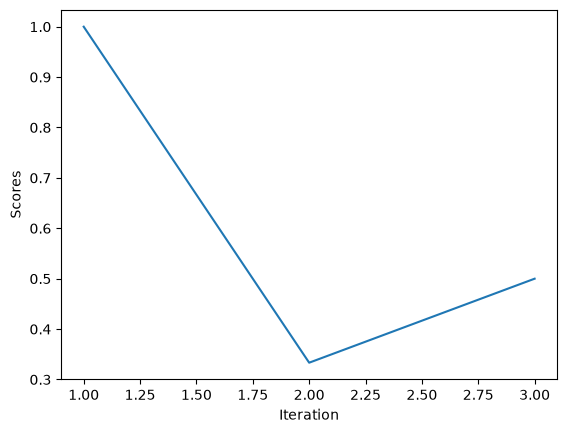

In [52]:
import matplotlib.pyplot as plt

plt.plot([1,2,3],scores)
plt.xlabel("Iteration")
plt.ylabel("Scores")

### 2. Deliberately introduce data leakage: fit the scaler on the full dataset before splitting. Compare the cross-validation score (leaky) to the pipeline cross-validation score (clean). How large is the difference?

In [27]:
# loading the data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [28]:
iris = load_iris()

In [29]:
X=iris["data"]
y=iris["target"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15)

Training before splitting 

In [31]:
model_leaky=RandomForestClassifier()

In [32]:
model_leaky.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
leaky_score = cross_val_score(model_leaky,X_test,y_test)

In [35]:
leaky_score

array([0.8, 1. , 1. , 1. , 1. ])

In [37]:
# build a pipeline 
preprocessor=Pipeline([
    ("scaler",StandardScaler()),
])

In [38]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

clean_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Clean CV:", clean_scores.mean())

Clean CV: 0.9666666666666668


In [39]:
clean_scores

array([0.96666667, 0.96666667, 0.93333333, 0.96666667, 1.        ])

Text(0.5, 1.0, 'Leaky Vs Clean Score')

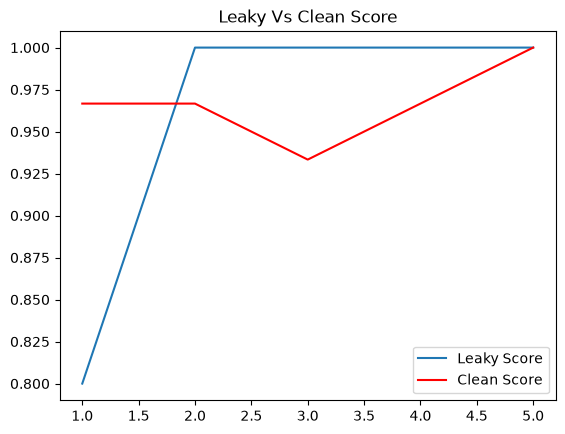

In [41]:
plt.plot([1,2,3,4,5],leaky_score,label="Leaky Score")
plt.plot([1,2,3,4,5],clean_scores,color="red" ,label="Clean Score")
plt.legend()
plt.title("Leaky Vs Clean Score")

### 03. Serialize your pipeline with joblib.dump. Load it in a separate script and run predictions. Verify the predictions are identical.

In [53]:
# main_pipeline
# this is the pipe line comes from the previous question no 1

In [69]:
import joblib
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


In [70]:
# Load dataset
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

# Add few missing values for imputer demo
X.iloc[5, 0] = np.nan
X.iloc[20, 2] = np.nan
X.iloc[40, 1] = np.nan

numeric_features = X.columns.tolist()



/var/folders/qb/x423dkzx7y352vrdk51r8_wm0000gn/T/ipykernel_76569/2211017462.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.iloc[5, 0] = np.nan
/var/folders/qb/x423dkzx7y352vrdk51r8_wm0000gn/T/ipykernel_76569/2211017462.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.iloc[20, 2] = np.nan
/var/folders/qb/x423dkzx7y352vrdk51r8_wm0000gn/T/ipykernel_76569/2211017462.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.iloc[40

In [71]:
# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features)
])

# Full pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])


In [72]:
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [73]:
predictions_before_saving=pipeline.predict(X)

In [75]:
joblib.dump(pipeline,"iris_pipeline.joblib")

['iris_pipeline.joblib']

In [76]:
saved_pipeline=joblib.load("iris_pipeline.joblib")

In [80]:
predictions_after_saving = saved_pipeline.predict(X)

In [81]:
print("Predictions identical:", np.array_equal(predictions_before_saving, predictions_after_saving))

Predictions identical: True


### 04.Add a custom transformer to the pipeline that creates polynomial features (degree 2) for the two most important numeric columns. Where should it go in the pipeline?

In [100]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures

class PolyTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, degree=2, include_bias=False):
        self.degree = degree
        self.include_bias = include_bias

    def fit(self, X, y=None):
        self.poly_ = PolynomialFeatures(
            degree=self.degree,
            include_bias=self.include_bias
        )
        self.poly_.fit(X)
        return self

    def transform(self, X):
        return self.poly_.transform(X)

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

poly_features = ["petal length (cm)", "petal width (cm)"]
other_features = [
    "sepal length (cm)",
    "sepal width (cm)"
]

poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolyTransformer()),
    ("scaler", StandardScaler())
])

other_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("poly", poly_pipeline, poly_features),
    ("other", other_pipeline, other_features)
])

main_poly_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [103]:
# cross_val_score(main_poly_pipeline,X_test,y_test)

### 05. Set up MLflow tracking for the pipeline. Run 5 experiments with different hyperparameters. Use the MLflow UI (mlflow ui) to compare runs and pick the best model.

See The ```mlflow_tracking.ipynb``` file for this 

In [104]:
import mlflow

In [105]:
import mlflow.sklearn

In [106]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Dataset
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [107]:

# Preprocessing
preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        X.columns
    )
])

In [108]:
experiments = [
    {"n_estimators": 50, "max_depth": 3},
    {"n_estimators": 100, "max_depth": 3},
    {"n_estimators": 100, "max_depth": 5},
    {"n_estimators": 200, "max_depth": 5},
    {"n_estimators": 300, "max_depth": None},
]



In [109]:
mlflow.set_experiment("Iris Random Forest")


2026/08/05 08:20:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/05 08:20:52 INFO mlflow.store.db.utils: Updating database tables
2026/08/05 08:20:54 INFO mlflow.tracking.fluent: Experiment with name 'Iris Random Forest' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/absyd/mystfs/cs/ai/coursingggs_/AI_ENG_FROM_SCRATCH/02-ml-fundamentals/exercises/mlruns/1', creation_time=1785896454969, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785896454969, lifecycle_stage='active', name='Iris Random Forest', tags={}, trace_location=None, workspace='default'>

In [110]:
for params in experiments:

    with mlflow.start_run():

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                random_state=42
            ))
        ])

        pipeline.fit(X_train, y_train)

        preds = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, preds)

        mlflow.log_params(params)
        mlflow.log_metric("accuracy", accuracy)

        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model"
        )

        print(params, accuracy)

2026/08/05 08:21:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The sklearn model could not be serialized in the skops serialization format. skops does not support custom functions or classes that are not defined at the top level. To work around this limitation, you can set the serialization_format 'cloudpickle', while exercising caution due to the possible arbitrary code during model deserialization using CloudPickle.